In [1]:
import numpy as np

# The Practical Problems of Quantum Linear System Solvers and a Krylov-based Solution -- Numerical example

In this tutorial we show how to use the code at https://github.com/MDeiml/quantum-krylov to benchmark quantum linear system solvers. This is done in two steps

1. We demonstrate the interface for solvers, specifically the `BlockEncodingModel` class
2. We simulate solvers for multiple problems and many combinations of parameters using the `Runner` class

## Defining linear solvers

Let us first set up a problem with condition $3$ and $1\%$ of noise. Our goal will be to solve this problem using a quantum algorithm.

> These parameters are not necessarily realistic. Real hardware has around $0.1\%$ of noise per two-qubit gate, and a typical matrix needs more than 10 two-qubit gates.

In [2]:
from block_encoding_model import BlockEncodingModel

dim = 10
kappa = 3

rng = np.random.default_rng(321)

b = rng.normal(size=dim)
b /= np.linalg.norm(b)
D = rng.uniform(1 / kappa, 1, size=dim)
print(f"D = {D}")
print(f"b = {b}")

problem = BlockEncodingModel(D, b, kappa=kappa, noise=0.01)

D = [0.97221033 0.58975786 0.84992502 0.60477004 0.92803303 0.93409294
 0.44114879 0.9487423  0.8422391  0.60592366]
b = [-0.21497392  0.13557584 -0.46869643 -0.47864193 -0.13694979 -0.04252458
  0.14466875 -0.28144783  0.53618361 -0.28005819]


The object `problem` now contains information representing an equation of the form $Dx = b$ where $D$ is diagonal with the given entries. Note that the condition of $D$ is not actually $3$, but in reality one often only has such upper bounds on the condition.

> It is enough to consider these diagonal matrices, since every symmetric matrix is equal to a diagonal one under a unitary change of basis.

The object `problem` further contains information to simulate the low-level behaviour of a block encoding, namely
* `problem.noise_flips`, encoding positions in the circuit where noise can be introduced, and
* `problem.noise = 0.01`, the probability that noise is introduced after an application of the block encoding.

To demonstrate how `problem` can be used, let us implement the QCheb polynomial

In [3]:
problem.reset()  # Reset the complexity counter, and the random generators

steps = 2
samples = 10000

X = np.polynomial.Chebyshev([0, 1])
poly = np.polynomial.Chebyshev([0] * steps + [0, 1])
poly = poly((X - (1 / problem.kappa**2 + 1) / 2) / (1 - 1 / problem.kappa**2) * 2)
poly = 1 - poly / poly(0)
poly = poly(X**2) // X

We can plot the polynomial, as well as the distribution of eigenvalues of the problem with the `plot_poly` utility function. This also weighs the eigenvalues by the overlap of the corresponding eigenvectors with $b$.

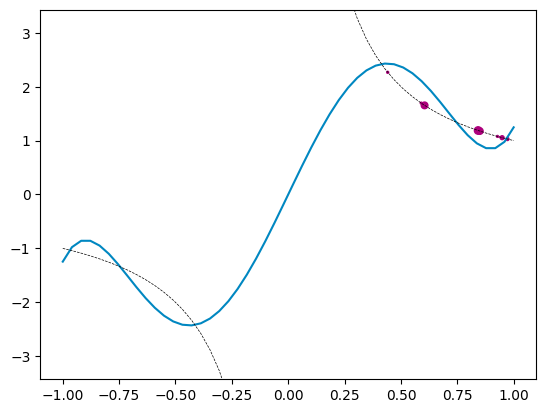

In [4]:
from util import plot_poly

plot_poly(poly, problem)

We observe that this does not interploate the eigenvalues well. At the important eigenvalues at $0.85$ and $0.6$, the polynomial is not close to $1/x$ (the dashed line). The positive definite structure of the problem is not used, with the negative part of $1/x$ being approximated as well. This is reflected by the error. The complexity counts, how often the block encoding is used, which in this case is $(2 \times \mathtt{steps} + 1) \times \mathtt{samples}$.

In [5]:
error = problem.estimate_error(poly, samples)
print(f"error = {error}")
complexity = problem.complexity()
print(f"complexity = {complexity}")

error = 0.10084524726350855
complexity = 50000


An implementation of this solver can also be found in `semi_iterative_solver.py`. Let us compare it with the CAP solver with the same polynomial degree and using the same measurement accuracy.

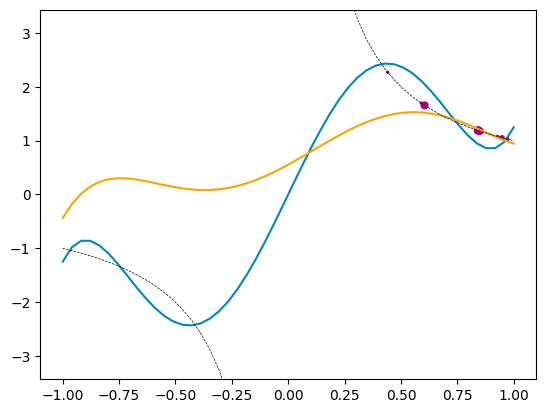

In [6]:
from cap_solver import cap_solver

problem.reset()

steps = 5
samples = 10000
adaptive = True  # adaptive = False gives CUP solver
transform = None # other options are "square" and "square_outer"

poly_adaptive = cap_solver(
    problem, steps, samples, transform, adaptive
)
plot_poly([poly, poly_adaptive], problem)
error_adaptive = problem.estimate_error(poly_adaptive, samples)
complexity_adaptive = problem.complexity()

The adaptive solver chooses to ignore the eigenvalue with small weight at $0.44$, which at this accuracy is sensible. It only approximates the positive part of $1/x$ while constraining the sup-norm of the polynomial. This improved error is reflected by the simulator. However, of course, the adaptive solver requires more measurements than the static one.

In [7]:
print(f"error QCheb      = {error}")
print(f"error CAP        = {error_adaptive}")
print(f"complexity QCheb = {complexity:6}")
print(f"complexity CAP   = {complexity_adaptive:6}")

error QCheb      = 0.10084524726350855
error CAP        = 0.03012708985153068
complexity QCheb =  50000
complexity CAP   = 410000


> This example should be taken with a grain of salt. If eigenvalues are distributed more uniformly, the difference will not be as stark.

## Benchmarking multiple parameters

To perform a more meaningful comparison, one can run solvers for multiple problems and different combination of parameters. This can of course be done by a simple loop, but the `Runner` class gives a simpliefied interface and handles logging of error statistics. Consider the following code.

In [10]:
from runner import Runner

runner = Runner({"kappa": [3], "noise": [0.00, 0.01], "num_clusters": [None]}, tries=3)
# One can also specify `dim`  and `error_percentiles`

runner.test_solver(
    cap_solver,
    "cap_example",
    {
        "steps": [3, 5],
        "samples": [5000, 10000],
        "transform": [None],
        "adaptive": [True],
    },
)

Checking git hash...
Consider creating a git commit before running to ensure proper tagging
Generating problems...


Testing cap_example(steps=5, samples=10000, transform=None, adaptive=True, noise=0.01, kappa=3, num_clusters=None): 100%|██████████| 4/4 [00:05<00:00,  1.30s/it]


This creates a file `results/cap_example_{git hash}.csv` containing the minimum, maximum, and median error, as well as 5th adn 95th percentiles. Each row specifies the problem and solver parameters.

In [11]:
filename = f"results/cap_example_{runner.commit_hash}.csv"
with open(filename) as f:
    columns = f.readline().strip().split(";")
    rows = [dict(zip(columns, line.strip().split(";"))) for line in f.readlines()]
print(f"columns: {', '.join(columns)}")
print("noise", "steps", "samples", "error 50 percentile", sep="\t")
for row in rows:
    print(
        row["noise"], row["steps"], row["samples"], row["error 50 percentile"], sep="\t"
    )

columns: steps, samples, transform, sup_norm_constraint, use_kappa, noise, kappa, num_clusters, complexity, error 0 percentile, error 5 percentile, error 50 percentile, error 95 percentile, error 100 percentile
noise	steps	samples	error 50 percentile
3	3	5000	0.0836796209853239
3	3	5000	0.06702830492962616
3	3	10000	0.06768168258064512
3	3	10000	0.04504272939457355
3	5	5000	0.04498231942390179
3	5	5000	0.05133364820678498
3	5	10000	0.05635238072948183
3	5	10000	0.047652820166823665


In a real world test one should of course increase the number of tries. The data for the adaptive and semi-iterative solvers from the paper is available at https://doi.org/10.5281/zenodo.19694861